# Arabic Text Classification: Traditional ML vs. Neural Models
In this notebook, we classify Arabic text from the AAFAQ dataset into various categories based on the `QuestionText`. 

We will compare the performance of two different preprocessing methods (`pyarabic` vs. `regex`) across multiple representation techniques and models:
1. **Representations**: Bag of Words (BoW), TF-IDF, and Static Word Embeddings (Word2Vec).
2. **Traditional Models**: Naive Bayes, Support Vector Machine (SVM), and XGBoost.
3. **Neural Language Model**: AraBERT (`asafaya/bert-base-arabic`).

In [17]:
!pip install xgboost gensim transformers datasets torch scikit-learn pandas --quiet

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import torch
import warnings

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from gensim.models import Word2Vec
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings to keep the notebook output clean
warnings.filterwarnings('ignore')

## 1. Data Loading and Preparation
We load both the PyArabic and Regex preprocessed datasets. We use `LabelEncoder` to convert the string categories into numerical labels required by machine learning algorithms.

In [2]:
def load_dataset(filepath):
    """Loads a preprocessed dataset, drops nulls, and encodes labels."""
    df = pd.read_csv(filepath)
    # Drop rows where heavy preprocessing might have erased all text
    df = df.dropna(subset=['QuestionText', 'Category']).reset_index(drop=True)
    
    le = LabelEncoder()
    df['Label'] = le.fit_transform(df['Category'])
    
    return df, le

print("Loading datasets...")
df_pyarabic, le_py = load_dataset('pyarabic_preprocessed_AAFAQ_Dataset.csv')
df_regex, le_reg = load_dataset('regex_preprocessed_AAFAQ_Dataset.csv')

print(f"PyArabic Dataset: {df_pyarabic.shape[0]} rows")
print(f"Regex Dataset: {df_regex.shape[0]} rows")

Loading datasets...
PyArabic Dataset: 5009 rows
Regex Dataset: 5009 rows


## 2. Traditional Models & Static Embeddings
We will define a unified pipeline that takes a dataset, extracts features using three diverse techniques, and evaluates our traditional machine learning models.

**Representations Used:**
*   **BoW (CountVectorizer):** Captures term frequencies (unigrams and bigrams).
*   **TF-IDF:** Down-weights highly common words and emphasizes unique, informative words.
*   **Word2Vec:** A custom static word embedding model trained from scratch on our training data.

In [18]:
from gensim.models import Word2Vec
from transformers import AutoTokenizer, AutoModel, Trainer, TrainingArguments
from datasets import Dataset

In [38]:
# Global store — all model results accumulate here for the final comparison table
results_store = []  # list of dicts: {dataset, model, features, accuracy, report}

## Split & Extract Features

In [15]:
# Determine device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device for neural extraction: {device}")

def extract_contextual_embeddings(texts, model_name, is_qwen=False):
    """
    Passes text through a pre-trained model and extracts the CLS token embedding 
    (or average pooling) to represent the entire sentence contextually.
    """
    print(f"  -> Loading {model_name}...")
    
    # Qwen requires trust_remote_code
    if is_qwen:
        tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
        model = AutoModel.from_pretrained(model_name, trust_remote_code=True).to(device)
        # Ensure padding token exists for Qwen
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token
    else:
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModel.from_pretrained(model_name).to(device)

    # Move model to evaluation mode
    model.eval()
    
    embeddings = []
    batch_size = 16 # Process in batches to avoid out-of-memory errors
    
    print(f"  -> Extracting embeddings for {len(texts)} texts...")
    for i in range(0, len(texts), batch_size):
        batch_texts = list(texts[i:i+batch_size])
        
        # Tokenize
        encoded_input = tokenizer(
            batch_texts, 
            padding=True, 
            truncation=True, 
            max_length=128, 
            return_tensors='pt'
        ).to(device)
        
        with torch.no_grad():
            outputs = model(**encoded_input)
            
            # Extract the last hidden state
            last_hidden_states = outputs.last_hidden_state
            
            # We use mean pooling across the sequence length to get a single vector per sentence
            # We multiply by attention mask to ignore padding tokens
            attention_mask = encoded_input['attention_mask'].unsqueeze(-1).expand(last_hidden_states.size()).float()
            sum_embeddings = torch.sum(last_hidden_states * attention_mask, 1)
            sum_mask = torch.clamp(attention_mask.sum(1), min=1e-9)
            mean_pooled = (sum_embeddings / sum_mask).cpu().numpy()
            
            embeddings.extend(mean_pooled)
            
    return np.array(embeddings)

Using device for neural extraction: cuda


In [ ]:
def extract_features_for_dataset(df, label_encoder, dataset_name):
    """
    Extract all features (BoW, TF-IDF, Word2Vec, AraBERT, Qwen) for a dataset.
    Returns: dict with all features and train/test splits
    """
    print(f"\n{'='*80}")
    print(f"EXTRACTING FEATURES FOR: {dataset_name}")
    print(f"{'='*80}")

    X = df['QuestionText']
    y = df['Label']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # ---------------------------------------------------------
    # FEATURE EXTRACTION
    # ---------------------------------------------------------
    
    # 1. Bag of Words
    print("\n[1/5] Extracting Bag of Words features...")
    cv_vec = CountVectorizer(max_features=5000, ngram_range=(1, 2))
    X_train_cv = cv_vec.fit_transform(X_train)
    X_test_cv = cv_vec.transform(X_test)

    # 2. TF-IDF
    print("[2/5] Extracting TF-IDF features...")
    tfidf_vec = TfidfVectorizer(max_features=5000)
    X_train_tfidf = tfidf_vec.fit_transform(X_train)
    X_test_tfidf = tfidf_vec.transform(X_test)

    # 3. Custom Word2Vec
    print("[3/5] Training Custom Word2Vec Embeddings...")
    X_train_tokens = [str(text).split() for text in X_train]
    X_test_tokens = [str(text).split() for text in X_test]
    w2v_model = Word2Vec(sentences=X_train_tokens, vector_size=100, window=5, min_count=1, workers=4)

    def get_sentence_vector(tokens, model):
        vectors = [model.wv[w] for w in tokens if w in model.wv]
        if len(vectors) == 0:
            return np.zeros(model.vector_size)
        return np.mean(vectors, axis=0)

    X_train_w2v = np.array([get_sentence_vector(tokens, w2v_model) for tokens in X_train_tokens])
    X_test_w2v = np.array([get_sentence_vector(tokens, w2v_model) for tokens in X_test_tokens])

    # 4. AraBERT Contextual Embeddings
    print("[4/5] Extracting AraBERT Contextual Embeddings...")
    bert_model_name = "aubmindlab/bert-base-arabertv02"
    X_train_bert = extract_contextual_embeddings(X_train, bert_model_name)
    X_test_bert = extract_contextual_embeddings(X_test, bert_model_name)

    # 5. Qwen Contextual Embeddings (Note: Requires high RAM/VRAM)
    print("[5/5] Extracting Qwen Contextual Embeddings...")
    qwen_model_name = "Qwen/Qwen2.5-0.5B"
    qwen_success = False
    X_train_qwen = None
    X_test_qwen = None
    try:
        X_train_qwen = extract_contextual_embeddings(X_train, qwen_model_name, is_qwen=True)
        X_test_qwen = extract_contextual_embeddings(X_test, qwen_model_name, is_qwen=True)
        qwen_success = True
    except Exception as e:
        print(f"  -> Skipping Qwen due to memory/loading limits: {e}")

    features = {
        'dataset_name': dataset_name,
        'label_encoder': label_encoder,
        'y_train': y_train,
        'y_test': y_test,
        'X_train_cv': X_train_cv,
        'X_test_cv': X_test_cv,
        'X_train_tfidf': X_train_tfidf,
        'X_test_tfidf': X_test_tfidf,
        'X_train_w2v': X_train_w2v,
        'X_test_w2v': X_test_w2v,
        'X_train_bert': X_train_bert,
        'X_test_bert': X_test_bert,
        'X_train_qwen': X_train_qwen,
        'X_test_qwen': X_test_qwen,
        'qwen_success': qwen_success
    }
    
    print(f"\n✓ Feature extraction completed for {dataset_name}")
    return features

In [ ]:
import os

def save_features_to_csv(features_dict, output_folder="extracted_features"):
    """
    Save dense array features to CSV files using pandas for future reuse.
    Saves: Word2Vec, AraBERT, and Qwen embeddings only.
    """
    dataset_name = features_dict['dataset_name']
    dataset_folder = os.path.join(output_folder, dataset_name.replace(" ", "_"))
    
    # Create folder if it doesn't exist
    os.makedirs(dataset_folder, exist_ok=True)
    
    print(f"\nSaving features to: {dataset_folder}/")
    
    # Save dense arrays as CSV using pandas
    print("  - Saving Word2Vec embeddings...")
    pd.DataFrame(features_dict['X_train_w2v']).to_csv(os.path.join(dataset_folder, "X_train_w2v.csv"), index=False, header=False)
    pd.DataFrame(features_dict['X_test_w2v']).to_csv(os.path.join(dataset_folder, "X_test_w2v.csv"), index=False, header=False)
    
    print("  - Saving AraBERT embeddings...")
    pd.DataFrame(features_dict['X_train_bert']).to_csv(os.path.join(dataset_folder, "X_train_bert.csv"), index=False, header=False)
    pd.DataFrame(features_dict['X_test_bert']).to_csv(os.path.join(dataset_folder, "X_test_bert.csv"), index=False, header=False)
    
    # Save Qwen if available
    if features_dict['qwen_success']:
        print("  - Saving Qwen embeddings...")
        pd.DataFrame(features_dict['X_train_qwen']).to_csv(os.path.join(dataset_folder, "X_train_qwen.csv"), index=False, header=False)
        pd.DataFrame(features_dict['X_test_qwen']).to_csv(os.path.join(dataset_folder, "X_test_qwen.csv"), index=False, header=False)
    
    print(f"✓ All features saved successfully for {dataset_name}!")
    return dataset_folder

# Extract features for both datasets
print("Starting feature extraction for both datasets...\n")

features_pyarabic = extract_features_for_dataset(df_pyarabic, le_py, "PyArabic Dataset")
features_regex = extract_features_for_dataset(df_regex, le_reg, "Regex Dataset")

print("\n" + "="*80)
print("FEATURE EXTRACTION COMPLETE")
print("="*80)

# Save features to CSV files
print("\n" + "="*80)
print("SAVING EXTRACTED FEATURES")
print("="*80)

save_features_to_csv(features_pyarabic)
save_features_to_csv(features_regex)

print("\n✓ All features have been saved to the 'extracted_features' folder!")


EVALUATING TRADITIONAL MODELS ON: PyArabic Dataset

[1/5] Extracting Bag of Words features...
[2/5] Extracting TF-IDF features...
[3/5] Training Custom Word2Vec Embeddings...
[4/5] Extracting AraBERT Contextual Embeddings...
  -> Loading aubmindlab/bert-base-arabertv02...


tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

  -> Extracting embeddings for 4007 texts...
  -> Loading Qwen/Qwen2.5-0.5B...
  -> Extracting embeddings for 1002 texts...

--- ACCURACY RESULTS ---

> NAIVE BAYES (MultinomialNB)
  - NB + BoW: 0.6916
  - NB + TF-IDF: 0.6337

> SUPPORT VECTOR MACHINE (LinearSVC)
  - SVM + BoW: 0.7186
  - SVM + TF-IDF: 0.7445
  - SVM + Word2Vec: 0.2186
  - SVM + AraBERT Embeddings: 0.7425
  - SVM + Qwen Embeddings: 0.6737

> XGBOOST
  - XGBoost + BoW: 0.6277
  - XGBoost + TF-IDF: 0.6008
  - XGBoost + Word2Vec: 0.4850
  - XGBoost + AraBERT Embeddings: 0.7295
  - XGBoost + Qwen Embeddings: 0.6697

Detailed Report for [XGBoost + AraBERT Embeddings] on PyArabic Dataset:
                  precision    recall  f1-score   support

 الاقتصاد والعمل       0.87      0.67      0.75        60
  البيئة والطاقة       0.76      0.79      0.78       102
      البيولوجيا       1.00      0.60      0.75        10
         التاريخ       0.77      0.77      0.77        84
         الترفيه       1.00      0.12      0.22    

KeyboardInterrupt: 

In [ ]:
def load_features_from_csv(dataset_folder):
    """
    Load previously extracted dense array features from CSV files using pandas.
    Loads: Word2Vec, AraBERT, and Qwen embeddings.
    
    Note: You'll need to re-extract BoW and TF-IDF features if needed, as only dense arrays are saved.
    
    Usage:
        features = load_features_from_csv("extracted_features/PyArabic_Dataset")
    """
    print(f"\nLoading features from: {dataset_folder}/")
    
    # Load dense arrays using pandas
    print("  - Loading Word2Vec embeddings...")
    X_train_w2v = pd.read_csv(os.path.join(dataset_folder, "X_train_w2v.csv"), header=None).values
    X_test_w2v = pd.read_csv(os.path.join(dataset_folder, "X_test_w2v.csv"), header=None).values
    
    print("  - Loading AraBERT embeddings...")
    X_train_bert = pd.read_csv(os.path.join(dataset_folder, "X_train_bert.csv"), header=None).values
    X_test_bert = pd.read_csv(os.path.join(dataset_folder, "X_test_bert.csv"), header=None).values
    
    # Check if Qwen features exist
    qwen_success = os.path.exists(os.path.join(dataset_folder, "X_train_qwen.csv"))
    X_train_qwen = None
    X_test_qwen = None
    if qwen_success:
        print("  - Loading Qwen embeddings...")
        X_train_qwen = pd.read_csv(os.path.join(dataset_folder, "X_train_qwen.csv"), header=None).values
        X_test_qwen = pd.read_csv(os.path.join(dataset_folder, "X_test_qwen.csv"), header=None).values
    
    print(f"✓ Features loaded successfully!")
    
    # Return features dict with loaded embeddings
    features = {
        'X_train_w2v': X_train_w2v,
        'X_test_w2v': X_test_w2v,
        'X_train_bert': X_train_bert,
        'X_test_bert': X_test_bert,
        'X_train_qwen': X_train_qwen,
        'X_test_qwen': X_test_qwen,
        'qwen_success': qwen_success
    }
    
    print(f"  - Word2Vec shape: {X_train_w2v.shape}")
    print(f"  - AraBERT shape: {X_train_bert.shape}")
    if qwen_success:
        print(f"  - Qwen shape: {X_train_qwen.shape}")
    return features

print("\n✓ Load function is ready! Use load_features_from_csv(folder_path) to reload embeddings.")

## 2.1 Training: Naive Bayes Models

In [ ]:
def train_naive_bayes(features_dict, results_store):
    """Train Naive Bayes on BoW and TF-IDF (it cannot handle negative values from embeddings)"""
    print(f"\n{'='*80}")
    print(f"TRAINING NAIVE BAYES: {features_dict['dataset_name']}")
    print(f"{'='*80}")
    
    dataset_name = features_dict['dataset_name']
    label_encoder = features_dict['label_encoder']
    y_train = features_dict['y_train']
    y_test = features_dict['y_test']
    
    # Naive Bayes with BoW
    print("\n[1/2] Training NB + BoW...")
    nb_bow = MultinomialNB()
    nb_bow.fit(features_dict['X_train_cv'], y_train)
    nb_bow_preds = nb_bow.predict(features_dict['X_test_cv'])
    nb_bow_acc = accuracy_score(y_test, nb_bow_preds)
    print(f"  Accuracy: {nb_bow_acc:.4f}")
    
    report_dict = classification_report(y_test, nb_bow_preds, target_names=label_encoder.classes_, 
                                       zero_division=0, output_dict=True)
    results_store.append({
        "Dataset": dataset_name,
        "Model": "Naive Bayes",
        "Features": "BoW",
        "Accuracy": round(nb_bow_acc, 4),
        "Macro F1": round(report_dict["macro avg"]["f1-score"], 4),
        "Weighted F1": round(report_dict["weighted avg"]["f1-score"], 4),
    })
    
    # Naive Bayes with TF-IDF
    print("[2/2] Training NB + TF-IDF...")
    nb_tfidf = MultinomialNB()
    nb_tfidf.fit(features_dict['X_train_tfidf'], y_train)
    nb_tfidf_preds = nb_tfidf.predict(features_dict['X_test_tfidf'])
    nb_tfidf_acc = accuracy_score(y_test, nb_tfidf_preds)
    print(f"  Accuracy: {nb_tfidf_acc:.4f}")
    
    report_dict = classification_report(y_test, nb_tfidf_preds, target_names=label_encoder.classes_, 
                                       zero_division=0, output_dict=True)
    results_store.append({
        "Dataset": dataset_name,
        "Model": "Naive Bayes",
        "Features": "TF-IDF",
        "Accuracy": round(nb_tfidf_acc, 4),
        "Macro F1": round(report_dict["macro avg"]["f1-score"], 4),
        "Weighted F1": round(report_dict["weighted avg"]["f1-score"], 4),
    })

# Train Naive Bayes on both datasets
train_naive_bayes(features_pyarabic, results_store)
train_naive_bayes(features_regex, results_store)

## 2.2 Training: Support Vector Machine (SVM) Models

In [ ]:
def train_svm(features_dict, results_store):
    """Train SVM on multiple embeddings: BoW, TF-IDF, Word2Vec, AraBERT, Qwen"""
    print(f"\n{'='*80}")
    print(f"TRAINING SVM: {features_dict['dataset_name']}")
    print(f"{'='*80}")
    
    dataset_name = features_dict['dataset_name']
    label_encoder = features_dict['label_encoder']
    y_train = features_dict['y_train']
    y_test = features_dict['y_test']
    svm_params = {'random_state': 42, 'dual': False, 'max_iter': 2000}
    
    feature_configs = [
        ("BoW", features_dict['X_train_cv'], features_dict['X_test_cv']),
        ("TF-IDF", features_dict['X_train_tfidf'], features_dict['X_test_tfidf']),
        ("Word2Vec", features_dict['X_train_w2v'], features_dict['X_test_w2v']),
        ("AraBERT Embeddings", features_dict['X_train_bert'], features_dict['X_test_bert']),
    ]
    
    if features_dict['qwen_success']:
        feature_configs.append(("Qwen Embeddings", features_dict['X_train_qwen'], features_dict['X_test_qwen']))
    
    for idx, (feat_name, X_train, X_test) in enumerate(feature_configs, 1):
        print(f"\n[{idx}/{len(feature_configs)}] Training SVM + {feat_name}...")
        svm = LinearSVC(**svm_params)
        svm.fit(X_train, y_train)
        preds = svm.predict(X_test)
        acc = accuracy_score(y_test, preds)
        print(f"  Accuracy: {acc:.4f}")
        
        report_dict = classification_report(y_test, preds, target_names=label_encoder.classes_, 
                                           zero_division=0, output_dict=True)
        results_store.append({
            "Dataset": dataset_name,
            "Model": "SVM",
            "Features": feat_name,
            "Accuracy": round(acc, 4),
            "Macro F1": round(report_dict["macro avg"]["f1-score"], 4),
            "Weighted F1": round(report_dict["weighted avg"]["f1-score"], 4),
        })

# Train SVM on both datasets
train_svm(features_pyarabic, results_store)
train_svm(features_regex, results_store)

## 2.3 Training: XGBoost Models

In [ ]:
def train_xgboost(features_dict, results_store):
    """Train XGBoost on multiple embeddings: BoW, TF-IDF, Word2Vec, AraBERT, Qwen"""
    print(f"\n{'='*80}")
    print(f"TRAINING XGBOOST: {features_dict['dataset_name']}")
    print(f"{'='*80}")
    
    dataset_name = features_dict['dataset_name']
    label_encoder = features_dict['label_encoder']
    y_train = features_dict['y_train']
    y_test = features_dict['y_test']
    xgb_params = {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 5, 'random_state': 42, 
                  'n_jobs': -1, 'tree_method': 'hist', 'verbosity': 0}
    
    feature_configs = [
        ("BoW", features_dict['X_train_cv'], features_dict['X_test_cv']),
        ("TF-IDF", features_dict['X_train_tfidf'], features_dict['X_test_tfidf']),
        ("Word2Vec", features_dict['X_train_w2v'], features_dict['X_test_w2v']),
        ("AraBERT Embeddings", features_dict['X_train_bert'], features_dict['X_test_bert']),
    ]
    
    if features_dict['qwen_success']:
        feature_configs.append(("Qwen Embeddings", features_dict['X_train_qwen'], features_dict['X_test_qwen']))
    
    for idx, (feat_name, X_train, X_test) in enumerate(feature_configs, 1):
        print(f"\n[{idx}/{len(feature_configs)}] Training XGBoost + {feat_name}...")
        xgb_model = xgb.XGBClassifier(**xgb_params)
        xgb_model.fit(X_train, y_train)
        preds = xgb_model.predict(X_test)
        acc = accuracy_score(y_test, preds)
        print(f"  Accuracy: {acc:.4f}")
        
        report_dict = classification_report(y_test, preds, target_names=label_encoder.classes_, 
                                           zero_division=0, output_dict=True)
        results_store.append({
            "Dataset": dataset_name,
            "Model": "XGBoost",
            "Features": feat_name,
            "Accuracy": round(acc, 4),
            "Macro F1": round(report_dict["macro avg"]["f1-score"], 4),
            "Weighted F1": round(report_dict["weighted avg"]["f1-score"], 4),
        })

# Train XGBoost on both datasets
train_xgboost(features_pyarabic, results_store)
train_xgboost(features_regex, results_store)

## 2.4 Model Comparison & Evaluation

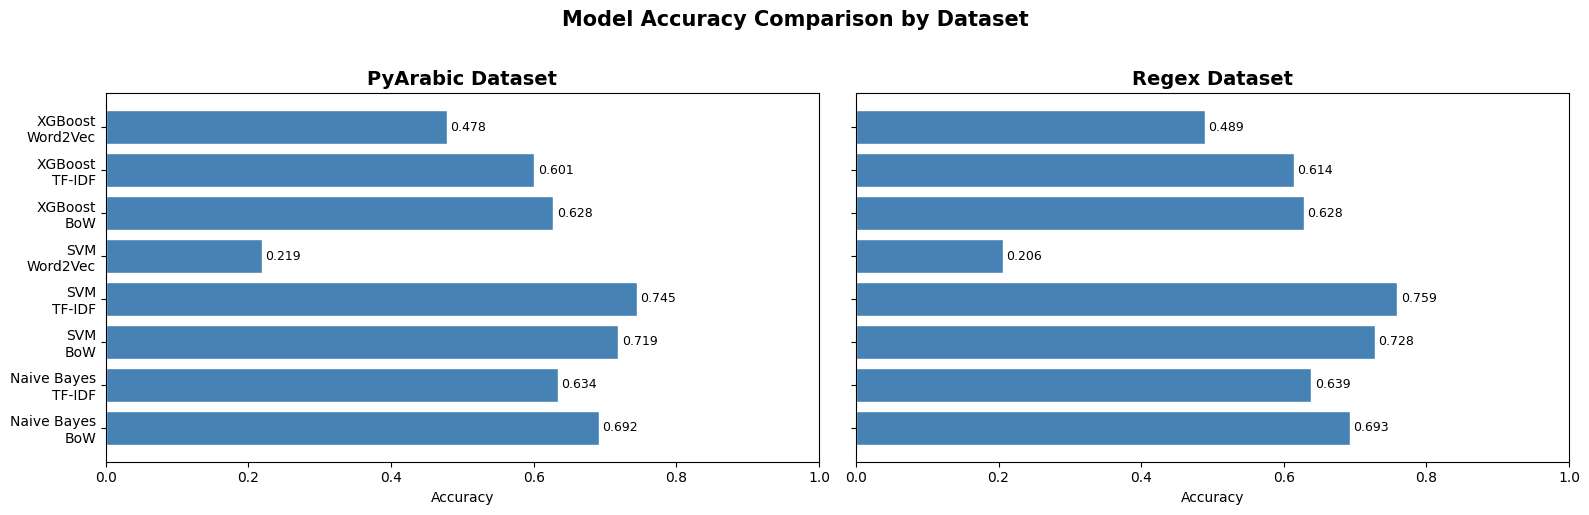

In [ ]:
# Create results DataFrame
results_df = pd.DataFrame(results_store)

# Display overall comparison table
print(f"\n{'='*80}")
print("OVERALL MODEL COMPARISON")
print(f"{'='*80}\n")

comparison = results_df.pivot_table(
    index=["Model", "Features"],
    columns="Dataset",
    values=["Accuracy", "Macro F1", "Weighted F1"]
).round(4)

# Highlight best per column
def highlight_max(s):
    is_max = s == s.max()
    return ['font-weight: bold' if v else '' for v in is_max]

display(
    comparison.style
    .apply(highlight_max, axis=0)
    .set_caption("Model Comparison — Accuracy, Macro F1, Weighted F1")
    .set_table_styles([{"selector": "caption",
                        "props": [("font-size", "15px"), ("font-weight", "bold")]}])
)

print("\n")

In [ ]:
# Visualization: PyArabic Dataset - Horizontal Bar Chart
print("="*80)
print("VISUALIZATION: PyArabic Dataset - Model Accuracies")
print("="*80)

pyarabic_df = results_df[results_df["Dataset"] == "PyArabic Dataset"].copy()
pyarabic_df = pyarabic_df.sort_values("Accuracy", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(pyarabic_df)))

bars = ax.barh(range(len(pyarabic_df)), pyarabic_df["Accuracy"], color=colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(pyarabic_df)))
ax.set_yticklabels([f"{row['Model']}\n({row['Features']})" for _, row in pyarabic_df.iterrows()], fontsize=10)
ax.set_xlabel("Accuracy", fontsize=12, fontweight='bold')
ax.set_xlim(0, 1)
ax.set_title("PyArabic Dataset - Model Accuracy Comparison", fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Add accuracy values on bars
for i, (idx, row) in enumerate(pyarabic_df.iterrows()):
    acc = row["Accuracy"]
    ax.text(acc + 0.01, i, f"{acc:.3f}", va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n")

In [ ]:
# Visualization: Regex Dataset - Horizontal Bar Chart
print("="*80)
print("VISUALIZATION: Regex Dataset - Model Accuracies")
print("="*80)

regex_df = results_df[results_df["Dataset"] == "Regex Dataset"].copy()
regex_df = regex_df.sort_values("Accuracy", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.plasma(np.linspace(0.3, 0.9, len(regex_df)))

bars = ax.barh(range(len(regex_df)), regex_df["Accuracy"], color=colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(regex_df)))
ax.set_yticklabels([f"{row['Model']}\n({row['Features']})" for _, row in regex_df.iterrows()], fontsize=10)
ax.set_xlabel("Accuracy", fontsize=12, fontweight='bold')
ax.set_xlim(0, 1)
ax.set_title("Regex Dataset - Model Accuracy Comparison", fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Add accuracy values on bars
for i, (idx, row) in enumerate(regex_df.iterrows()):
    acc = row["Accuracy"]
    ax.text(acc + 0.01, i, f"{acc:.3f}", va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n")

## 3. Neural Language Model (AraBERT)
Unlike traditional models that rely on frequency arrays or static vectors, AraBERT is a contextual transformer. It learns the meaning of a word based on the surrounding text. 

We will fine-tune `asafaya/bert-base-arabic` on our classification task.

In [57]:
# this solves the huggingface trainer error in the transformer section
!pip install "accelerate>=0.26.0"
!pip install transformers[torch]

In [3]:
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from datasets import Dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    Trainer, 
    TrainingArguments
)

In [ ]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc}

def evaluate_arabert(df, label_encoder, dataset_name):
    print(f"\n{'='*70}")
    print(f"TRAINING AraBERT ON: {dataset_name}")
    print(f"{'='*70}")
    
    model_name = "asafaya/bert-base-arabic"
    num_labels = len(label_encoder.classes_)
    
    # Train/Test Split
    train_texts, test_texts, train_labels, test_labels = train_test_split(
        df['QuestionText'].tolist(), df['Label'].tolist(), 
        test_size=0.2, random_state=42, stratify=df['Label'].tolist()
    )
    
    print("Tokenizing texts...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
    test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=128)
    
    # Convert to HuggingFace Dataset format
    train_dataset = Dataset.from_dict({'input_ids': train_encodings['input_ids'], 'attention_mask': train_encodings['attention_mask'], 'labels': train_labels})
    test_dataset = Dataset.from_dict({'input_ids': test_encodings['input_ids'], 'attention_mask': test_encodings['attention_mask'], 'labels': test_labels})
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Loading model onto {device}...")
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels).to(device)
    
    # Training Arguments
    training_args = TrainingArguments(
        output_dir=f'./results_{dataset_name.replace(" ", "_")}',
        num_train_epochs=1,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=64,
        warmup_steps=500,
        weight_decay=0.01,
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="epoch",
        report_to="none" # Disable W&B prompts
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics
    )
    
    print("Starting Fine-tuning...")
    trainer.train()
    
    print("\nEvaluating Model...")
    predictions = trainer.predict(test_dataset)
    preds = predictions.predictions.argmax(-1)
    
    print(f"\n[AraBERT Classification Report - {dataset_name}]")
    # Get classification report as dictionary and convert to DataFrame
    report_dict = classification_report(test_labels, preds, target_names=label_encoder.classes_, 
                                       zero_division=0, output_dict=True)
    report_df = pd.DataFrame(report_dict).transpose()
    display(report_df)

In [11]:
# Note: Training BERT takes significantly more computational power and time. 

# Run AraBERT on the PyArabic data
evaluate_arabert(df_pyarabic, le_py, "PyArabic Dataset")

# Run AraBERT on the Regex data
# evaluate_arabert(df_regex, le_reg, "Regex Dataset")


TRAINING AraBERT ON: PyArabic Dataset
Tokenizing texts...
Loading model onto cuda...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at asafaya/bert-base-arabic and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting Fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy
1,1.179700,1.047274,0.708583



Evaluating Model...


...

Starting Fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy
1,1.273800,1.137051,0.682635



Evaluating Model...



[AraBERT Classification Report - Regex Dataset]


,precision,recall,f1-score,support
الاقتصاد والعمل,0.736842,0.700000,0.717949,60.000000
البيئة والطاقة,0.724490,0.696078,0.710000,102.000000
البيولوجيا,0.000000,0.000000,0.000000,10.000000
التاريخ,0.603306,0.869048,0.712195,84.000000
الترفيه,0.000000,0.000000,0.000000,8.000000
التطوع,0.000000,0.000000,0.000000,5.000000
التعليم,0.765957,0.576000,0.657534,125.000000
التكنولوجيا,0.884058,0.670330,0.762500,91.000000
الثقافة,0.676647,0.738562,0.706250,153.000000
الجغرافيا,0.833333,0.714286,0.769231,42.000000
